# UK Flood Nowcasting Tool

Standalone tool: query any datetime in the processed archive (2024-01-01 to 2026-06-30) and get a full-UK 6h-ahead flood risk map, a quantile confidence-interval fan chart, and a printed summary — using both the trained ConvLSTM and 3D-CNN models. Self-contained — loads checkpoints directly, doesn't depend on ML_MODELS.ipynb having been run.

**Coverage limits:** dates before ~2014 (no IMERG satellite precipitation data exists that far back) or after 2026-06-30 (true live data would need `ERA5-1.ipynb`/`IMERG.ipynb` re-run for new hours first, then merged and converted the same way as the rest of the archive) are out of scope for this tool as-is.

**Usage:** run all cells top to bottom once (loads both models — a few seconds), then edit `TARGET_DATETIME` in the last cell and re-run just that cell to query a different time.

**Kernel:** use the "Dissertation venv" kernel (`w:\Dissertation\.venv`) — it has all required packages (torch cu128, pandas, matplotlib) already installed.

In [1]:
# REUSABLE NOWCASTING TOOL — SETUP
# ============================================================================
# Loads both trained models and everything needed to answer: "given the
# last 12 hours of data ending at some datetime, what's the flood risk
# 6 hours later, across the whole UK, with a confidence interval?"
#
# COVERAGE: the processed archive spans 2024-01-01T00:00 to 2026-06-30T23:00
# (train+val+test combined). A target datetime must fall in that range —
# and must be at least 12 hours after 2024-01-01T00:00 so a full lookback
# window exists. Querying outside this range (e.g. a pre-2000 historical
# flood, or truly live/future data) is NOT possible with this tool as-is:
#   - Pre-~2014 dates: IMERG satellite precipitation (3 of the 20 input
#     channels) doesn't exist that far back. A model trained without the
#     IMERG channels would be needed for genuinely old events.
#   - Post-2026-06-30 "live" dates: would need ERA5-1.ipynb / IMERG.ipynb
#     re-run to collect and process new hours first — a data-engineering
#     step, not something this tool does automatically.
# This tool is self-contained — it doesn't depend on any earlier cell's
# in-memory state, so it can be run independently after a kernel restart.
# ============================================================================
import os
import subprocess
import sys

for package in ["matplotlib", "pandas"]:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from convlstm_model import ConvLSTMForecaster, WeightedPinballLoss
from cnn3d_model import CNN3DForecaster

SEAGATE = "W:\Dissertation\Volumes\Seagate_2TB"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

N_LAT, N_LON   = 140, 131
N_FEATURES     = 20
N_QUANTILES    = 10
SEQ_LEN        = 12
PATCH_SIZE     = 64
HALF           = 32
QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
MED_IDX        = QUANTILE_LEVELS.index(0.5)
IMERG_CHANNELS = [10, 11, 12]

ARCHIVE_START = pd.Timestamp("2024-01-01T00:00:00")
ARCHIVE_END   = pd.Timestamp("2026-06-30T23:00:00")
TRAIN_END, VAL_END = 15335, 17543  # hour-index boundaries used throughout this project

SPLIT_FILES = {
    "train": ("train_X.npy", "train_y.npy"),
    "val":   ("val_X.npy", "val_y.npy"),
    "test":  ("test_X.npy", "test_y.npy"),
}


def load_model(kind):
    ckpt_dir = os.path.join(SEAGATE, "model_checkpoints",
                             "ConvLSTM" if kind == "convlstm" else "CNN3D")
    ckpt = torch.load(os.path.join(ckpt_dir, "best.pt"),
                       map_location=device, weights_only=False)
    mean = np.load(os.path.join(ckpt_dir, "feature_mean.npy"))
    std  = np.load(os.path.join(ckpt_dir, "feature_std.npy"))
    if kind == "convlstm":
        model = ConvLSTMForecaster(in_channels=N_FEATURES, hidden_dims=(64, 128, 64),
                                    n_quantiles=N_QUANTILES, dropout=0.15).to(device)
    else:
        model = CNN3DForecaster(in_channels=N_FEATURES, n_quantiles=N_QUANTILES,
                                 dropout=0.15).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, mean, std


print("Loading ConvLSTM and 3D-CNN checkpoints...")
convlstm, cl_mean, cl_std = load_model("convlstm")
cnn3d, c3_mean, c3_std    = load_model("cnn3d")
print("Models ready.")

# Land mask (static across time) — reuse train_X's first hour, memory-mapped
# so this doesn't load the full 22.5GB file into RAM.
_train_X_mmap = np.load(os.path.join(SEAGATE, "train_X.npy"), mmap_mode="r")
land_mask_full = np.array(_train_X_mmap[0, 13])  # is_land channel
if land_mask_full.max() == 0:
    land_mask_full = np.array(_train_X_mmap[0, 16])  # soil_average_soil fallback
all_land_cells = [(lat, lon) for lat in range(N_LAT) for lon in range(N_LON)
                   if land_mask_full[lat, lon] > 0.0]
del _train_X_mmap
print(f"Land cells: {len(all_land_cells):,}")


<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\zd827032\AppData\Local\Temp\ipykernel_16184\744748869.py:38: SyntaxWarning: invalid escape sequence '\D'
  SEAGATE = "W:\Dissertation\Volumes\Seagate_2TB"


Device: cuda
Loading ConvLSTM and 3D-CNN checkpoints...


Models ready.
Land cells: 5,058


In [2]:
# REUSABLE NOWCASTING TOOL — run_nowcast(target_datetime)
# ============================================================================
# Resolves a target datetime to the right 12h lookback window (wherever it
# falls in the archive — old train/val/test boundaries are irrelevant to
# the caller), runs both models across the full UK grid, and produces:
#   - A full-domain spatial map (actual-if-available vs both models' medians)
#   - A quantile fan chart (confidence interval over time) at the
#     highest-predicted-risk location for this query
#   - A printed confidence-interval summary at that location
# De-bands the known IMERG regridding-artefact latitude bands the same way
# as the main evaluation cell (see merged_datas.ipynb for the diagnosis).
# ============================================================================

def resolve_datetime(target_dt):
    target_dt = pd.Timestamp(target_dt)
    if target_dt < ARCHIVE_START or target_dt > ARCHIVE_END:
        raise ValueError(
            f"'{target_dt}' is outside the processed archive "
            f"({ARCHIVE_START} to {ARCHIVE_END}). This tool can't answer "
            f"for dates before the archive (e.g. pre-2014 historical floods "
            f"— IMERG satellite data doesn't exist that far back) or after "
            f"it (true live data needs ERA5-1.ipynb/IMERG.ipynb re-run for "
            f"the new hours first).")
    global_hour = int((target_dt - ARCHIVE_START) / pd.Timedelta(hours=1))
    if global_hour <= TRAIN_END:
        split, local_hour = "train", global_hour
    elif global_hour <= VAL_END:
        split, local_hour = "val", global_hour - (TRAIN_END + 1)
    else:
        split, local_hour = "test", global_hour - (VAL_END + 1)
    seq_end = local_hour + 1  # lookback window = [seq_end-SEQ_LEN, seq_end)
    if seq_end < SEQ_LEN:
        raise ValueError(
            f"'{target_dt}' is too close to the start of the archive — "
            f"needs {SEQ_LEN} full hours of lookback before it.")
    return split, seq_end


def deband_rows_2d(arr2d, bad_rows, good_rows):
    out = arr2d.copy()
    for col in range(arr2d.shape[1]):
        col_vals = arr2d[:, col]
        valid = ~np.isnan(col_vals)
        src_rows = np.array([r for r in good_rows if valid[r]])
        if len(src_rows) < 2:
            continue
        targets = np.array([r for r in bad_rows if valid[r]])
        if len(targets) == 0:
            continue
        out[targets, col] = np.interp(targets, src_rows, col_vals[src_rows])
    return out


def detect_bad_rows(X_full):
    """Detect artefact latitude bands from a persistently-zero IMERG
    precipitation signature (see merged_datas.ipynb diagnosis)."""
    precip = X_full[:, 10, :, :]
    zero_frac = np.zeros(N_LAT)
    for lat in range(N_LAT):
        cols = land_mask_full[lat] > 0
        if cols.sum() == 0:
            continue
        zero_frac[lat] = (precip[:, lat, cols] == 0).mean()
    baseline = pd.Series(zero_frac).rolling(9, center=True, min_periods=1).median().to_numpy()
    bad = np.where(zero_frac > baseline + 0.15)[0]
    good = np.array([r for r in range(N_LAT) if r not in set(bad.tolist())])
    return bad, good


def padded_patch(window_debanded, mean, std, lat_c, lon_c):
    Xs = (window_debanded - mean) / std
    Xs_pad = np.pad(Xs, ((0, 0), (0, 0), (HALF, HALF), (HALF, HALF)), mode="reflect")
    return Xs_pad[:, :, lat_c:lat_c+PATCH_SIZE, lon_c:lon_c+PATCH_SIZE]


def full_domain_predict(model, window_debanded, mean, std, batch_size=64):
    grid = np.full((N_LAT, N_LON, N_QUANTILES), np.nan, dtype=np.float32)
    Xs = (window_debanded - mean) / std
    Xs_pad = np.pad(Xs, ((0, 0), (0, 0), (HALF, HALF), (HALF, HALF)), mode="reflect")
    with torch.no_grad():
        for i in range(0, len(all_land_cells), batch_size):
            batch_centres = all_land_cells[i:i+batch_size]
            xb = np.stack([Xs_pad[:, :, lat_c:lat_c+PATCH_SIZE, lon_c:lon_c+PATCH_SIZE]
                            for lat_c, lon_c in batch_centres])
            xb = torch.from_numpy(xb).float().to(device)
            pred = model(xb, sort_quantiles=True).cpu().numpy()  # (B, 9, 64, 64)
            for (lat_c, lon_c), p in zip(batch_centres, pred):
                grid[lat_c, lon_c, :] = p[:, HALF, HALF]
    return grid  # (140, 131, 9)


def run_nowcast(target_datetime, fan_window_hours=150, save_prefix="nowcast"):
    print(f"\n{'='*70}\nNOWCAST QUERY: {target_datetime}\n{'='*70}")
    split, seq_end = resolve_datetime(target_datetime)
    xpath, ypath = SPLIT_FILES[split]
    X_mmap = np.load(os.path.join(SEAGATE, xpath), mmap_mode="r")
    Y_mmap = np.load(os.path.join(SEAGATE, ypath), mmap_mode="r")
    print(f"Resolved to split='{split}', local index {seq_end} "
          f"(lookback hours {seq_end-SEQ_LEN} to {seq_end-1}, predicting +6h from there)")

    window = np.array(X_mmap[seq_end-SEQ_LEN:seq_end])  # (12, 20, 140, 131)
    bad_rows, good_rows = detect_bad_rows(window)
    window_debanded = window.copy()
    for h in range(window.shape[0]):
        for ch in IMERG_CHANNELS:
            window_debanded[h, ch] = deband_rows_2d(window[h, ch], bad_rows, good_rows)
    print(f"De-banded {len(bad_rows)} known regridding-artefact latitude rows in this window")

    has_actual = seq_end < Y_mmap.shape[0]
    actual_full = deband_rows_2d(np.array(Y_mmap[seq_end]), bad_rows, good_rows) if has_actual else None

    print("Running full-domain ConvLSTM inference...")
    cl_grid = full_domain_predict(convlstm, window_debanded, cl_mean, cl_std)
    print("Running full-domain 3D-CNN inference...")
    c3_grid = full_domain_predict(cnn3d, window_debanded, c3_mean, c3_std)

    cl_med = cl_grid[:, :, MED_IDX]
    c3_med = c3_grid[:, :, MED_IDX]

    # ---- Spatial map ----
    panels = [(cl_med, "ConvLSTM median"), (c3_med, "3D-CNN median")]
    if has_actual:
        panels = [(actual_full, f"Actual (if available)")] + panels
    fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 6.5))
    if len(panels) == 1:
        axes = [axes]
    vmax = max(100, np.nanmax(cl_med), np.nanmax(c3_med))
    for ax, (data, title) in zip(axes, panels):
        im = ax.imshow(np.ma.masked_invalid(data), cmap="YlOrRd", vmin=0, vmax=vmax, origin="lower")
        ax.set_title(title)
        ax.set_xlabel("lon idx"); ax.set_ylabel("lat idx")
        plt.colorbar(im, ax=ax, fraction=0.03, label="flood_composite_6h_ahead")
    fig.suptitle(f"6h-ahead flood risk nowcast for {target_datetime}\n"
                 f"(archive lookup — de-banded, full UK grid)")
    plt.tight_layout()
    map_path = os.path.join(SEAGATE, "model_logs", f"{save_prefix}_map.png")
    plt.savefig(map_path, dpi=120, bbox_inches="tight")
    plt.show()

    # ---- Confidence summary at peak-risk location ----
    combined_med = np.nanmax(np.stack([np.nan_to_num(cl_med, nan=-1),
                                        np.nan_to_num(c3_med, nan=-1)]), axis=0)
    peak_lat, peak_lon = (int(x) for x in np.unravel_index(np.nanargmax(combined_med), combined_med.shape))
    print(f"\nPeak-risk location this query: lat={peak_lat}, lon={peak_lon}")
    for name, grid in [("ConvLSTM", cl_grid), ("3D-CNN", c3_grid)]:
        q = grid[peak_lat, peak_lon]
        print(f"  {name}: median={q[MED_IDX]:.1f}  "
              f"80% CI=[{q[1]:.1f}, {q[7]:.1f}]  10-90% range=[{q[0]:.1f}, {q[8]:.1f}]")
    if has_actual:
        print(f"  Actual (if available): {actual_full[peak_lat, peak_lon]:.1f}")

    # ---- Quantile fan chart around the query, at the peak-risk location ----
    half_window = fan_window_hours // 2
    fan_lo = max(SEQ_LEN, seq_end - half_window)
    fan_hi = min(X_mmap.shape[0] - 1, seq_end + half_window)
    fan_seq_ends = list(range(fan_lo, fan_hi))

    def run_fan(model, mean, std):
        preds = []
        with torch.no_grad():
            for se in fan_seq_ends:
                w = np.array(X_mmap[se-SEQ_LEN:se])
                for ch in IMERG_CHANNELS:
                    w[:, ch] = np.stack([deband_rows_2d(w[t, ch], bad_rows, good_rows)
                                          for t in range(w.shape[0])])
                patch = padded_patch(w, mean, std, peak_lat, peak_lon)
                xb = torch.from_numpy(patch).float().unsqueeze(0).to(device)
                pred = model(xb, sort_quantiles=True)
                preds.append(pred[0, :, HALF, HALF].cpu().numpy())
        return np.stack(preds)

    print("\nBuilding quantile fan chart around the query...")
    cl_fan = run_fan(convlstm, cl_mean, cl_std)
    c3_fan = run_fan(cnn3d, c3_mean, c3_std)
    actual_fan = np.array([Y_mmap[se, peak_lat, peak_lon]
                            if se < Y_mmap.shape[0] else np.nan for se in fan_seq_ends])

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, sharey=True)
    query_x = seq_end - fan_lo
    for ax, fan, title in zip(axes, [cl_fan, c3_fan], ["ConvLSTM", "3D-CNN"]):
        x = np.arange(len(fan_seq_ends))
        ax.fill_between(x, fan[:, 0], fan[:, 8], alpha=0.15, color="tab:blue", label="10-90%")
        ax.fill_between(x, fan[:, 1], fan[:, 7], alpha=0.25, color="tab:blue", label="20-80%")
        ax.fill_between(x, fan[:, 2], fan[:, 6], alpha=0.35, color="tab:blue", label="30-70%")
        ax.plot(x, fan[:, MED_IDX], color="tab:blue", lw=1.5, label="median (50%)")
        ax.plot(x, actual_fan, color="black", lw=1.2, ls="--", label="actual (if available)")
        ax.axvline(query_x, color="red", lw=1, ls=":", label="query time")
        ax.set_title(f"{title} — 6h-ahead quantile forecast at (lat={peak_lat}, lon={peak_lon})")
        ax.set_ylabel("flood_composite_6h_ahead")
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel(f"hour (relative to window start, query at x={query_x})")
    plt.tight_layout()
    fan_path = os.path.join(SEAGATE, "model_logs", f"{save_prefix}_fan.png")
    plt.savefig(fan_path, dpi=120, bbox_inches="tight")
    plt.show()

    print(f"\nSaved: {map_path}\nSaved: {fan_path}")
    return {"cl_grid": cl_grid, "c3_grid": c3_grid, "actual_full": actual_full,
            "peak_location": (peak_lat, peak_lon)}


print("run_nowcast(target_datetime) is ready.")
print(f"Valid range: {ARCHIVE_START} to {ARCHIVE_END}")


run_nowcast(target_datetime) is ready.
Valid range: 2024-01-01 00:00:00 to 2026-06-30 23:00:00



NOWCAST QUERY: 2026-01-15T06:00:00
Resolved to split='test', local index 343 (lookback hours 331 to 342, predicting +6h from there)
De-banded 26 known regridding-artefact latitude rows in this window
Running full-domain ConvLSTM inference...
Running full-domain 3D-CNN inference...


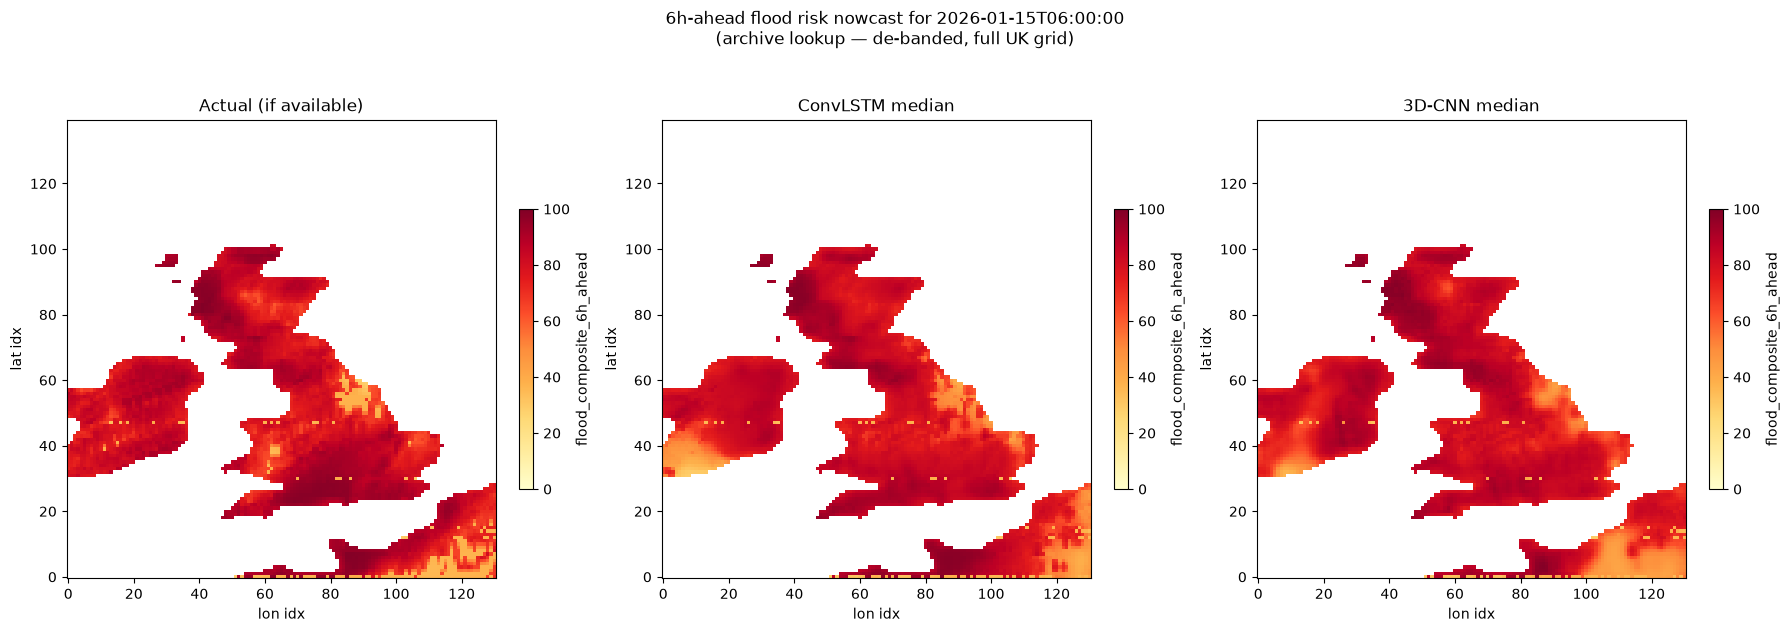


Peak-risk location this query: lat=0, lon=85
  ConvLSTM: median=98.9  80% CI=[91.6, 108.3]  10-90% range=[88.5, 115.1]
  3D-CNN: median=97.9  80% CI=[89.5, 107.9]  10-90% range=[85.2, 115.2]
  Actual (if available): 97.0

Building quantile fan chart around the query...


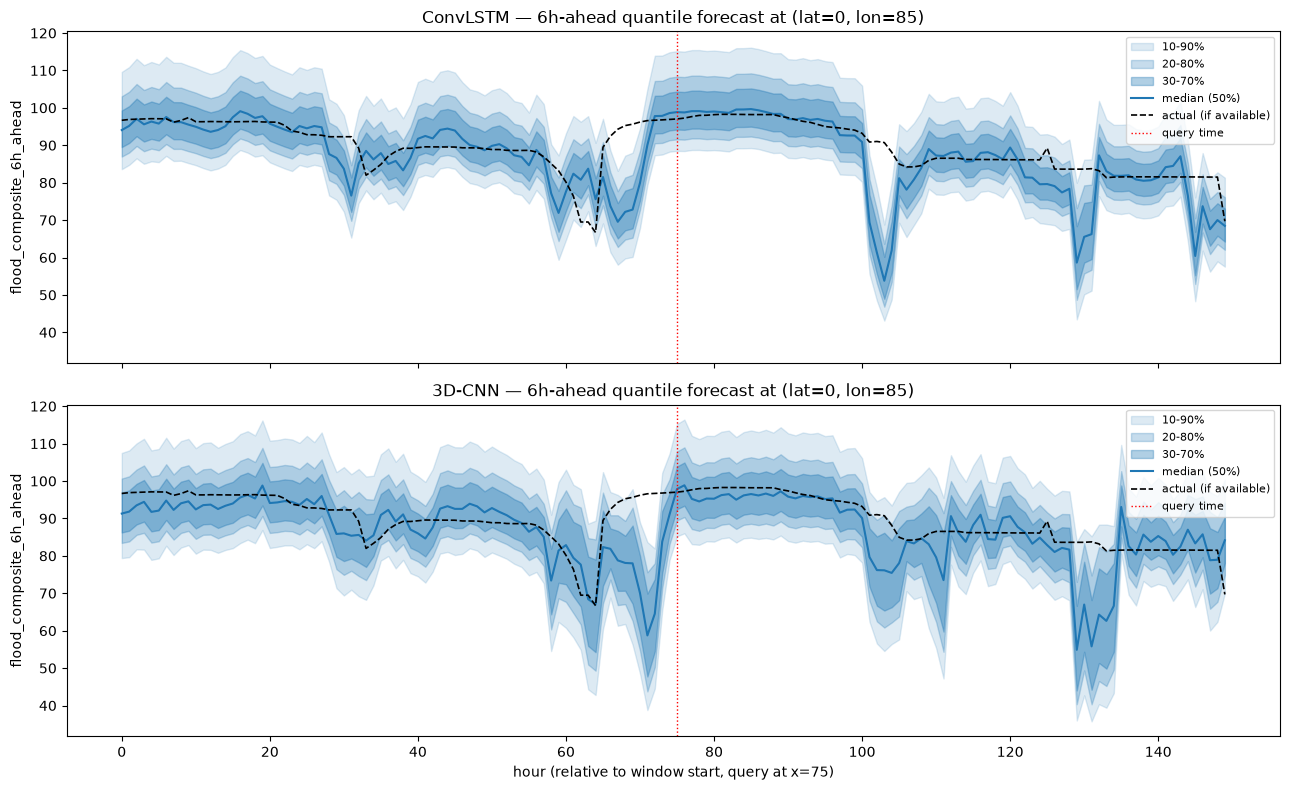


Saved: W:\Dissertation\Volumes\Seagate_2TB\model_logs\nowcast_map.png
Saved: W:\Dissertation\Volumes\Seagate_2TB\model_logs\nowcast_fan.png


In [7]:
# EXAMPLE — run a nowcast query for any datetime in the archive
# ============================================================================
# Change TARGET_DATETIME to any hour between 2024-01-01T12:00:00 and
# 2026-06-30T23:00:00 and re-run this cell. Produces the same full-UK map
# and quantile fan chart as the fixed test-set evaluation earlier, plus a
# printed confidence-interval summary — for whatever date you pick.
# ============================================================================
TARGET_DATETIME = "2026-01-15T06:00:00"  # <-- change this to query a different time

result = run_nowcast(TARGET_DATETIME)


# LIVE NOWCASTING — fetch the freshest available data and predict

Unlike the archive lookup above (bounded to 2024-01-01 to 2026-06-30), this section pulls **real, fresh data directly from ERA5 (Copernicus CDS) and IMERG (NASA Earthdata)** and feeds it straight into the same trained models — no retraining, no archive rebuild.

**Requires** `~/.cdsapirc` with a valid CDS API key (see the setup cell for how it's used) and a valid Earthdata token (already embedded, expires 2026-09-22 — replace it via the `EARTHDATA_TOKEN` env var once it does).

**A real, unavoidable constraint, not a bug:** ERA5's final product lags real time by ~5 days — `find_latest_era5_hour()` discovers the actual current boundary dynamically (by parsing CDS's own rejection message), so "live" here means *the freshest data ERA5 has actually published*, and the prediction is for 6 hours after that — not for this literal instant. IMERG's version tag (V07B/V07C/...) is also discovered dynamically via NASA's live CMR catalog rather than hardcoded, since GES DISC periodically bumps it.

Run the two setup/function cells above first (loads the models), then run these three cells in order.

In [3]:
# LIVE DATA — FETCH LATEST AVAILABLE ERA5
# ============================================================================
# Downloads the most recent available ERA5 reanalysis window directly from
# the Copernicus Climate Data Store (requires ~/.cdsapirc — see setup cell).
#
# IMPORTANT CONSTRAINT (discovered empirically, not a bug): ERA5's final,
# quality-controlled product lags real time by ~5 days (CDS serves a
# preliminary "ERA5T" version up to that point, nothing more recent). So
# "latest available" is never literally "right now" — it's whatever ERA5
# has actually published. find_latest_era5_hour() discovers this
# dynamically by parsing the CDS server's own rejection message, so it
# stays correct as the lag changes over time.
#
# Only the 13 ERA5 variables actually used by the trained models are
# requested (not all 18 originally collected) — u10/v10 (for wind_speed10),
# d2m, t2m, msl, sst, swvl1, z, cape, tcwv, blh, cp, lsm.
# ============================================================================
import os
import tempfile
import zipfile
import cdsapi
import numpy as np
import pandas as pd
import xarray as xr


def _open_cds_download(path):
    """CDS sometimes returns a ZIP (even when netcdf format was requested,
    e.g. when a request spans a variable naming change) instead of a raw
    .nc file — same quirk ERA5-1.ipynb's open_month() handles. Detect by
    content, not extension, and transparently extract+merge if needed."""
    if zipfile.is_zipfile(path):
        tmpdir = tempfile.mkdtemp()
        with zipfile.ZipFile(path) as z:
            z.extractall(tmpdir)
            names = z.namelist()
        parts = [xr.open_dataset(os.path.join(tmpdir, n)) for n in names]
        return xr.merge(parts, compat="override", join="outer")
    return xr.open_dataset(path)

ERA5_VARIABLES = [
    "10m_u_component_of_wind", "10m_v_component_of_wind",
    "2m_dewpoint_temperature", "2m_temperature",
    "mean_sea_level_pressure", "sea_surface_temperature",
    "volumetric_soil_water_layer_1", "geopotential",
    "convective_available_potential_energy", "total_column_water_vapour",
    "land_sea_mask", "convective_precipitation", "boundary_layer_height",
]
# Padded UK area (same +1.5deg buffer as the original archive build, so
# linear interpolation onto the target grid has real data on all sides —
# see ERA5-1.ipynb). [North, West, South, East]
ERA5_AREA = [62.5, -9.75, 48.5, 3.25]
PAD = 1.5
ERA5_AREA_PADDED = [round(v * 4) / 4 for v in
                     [ERA5_AREA[0] + PAD, ERA5_AREA[1] - PAD,
                      ERA5_AREA[2] - PAD, ERA5_AREA[3] + PAD]]

TARGET_LAT = np.arange(48.5, 62.4 + 0.05, 0.1)  # 140 points, matches archive exactly
TARGET_LON = np.arange(-9.75, 3.25 + 0.05, 0.1)  # 131 points

LIVE_DATA_DIR = os.path.join(SEAGATE, "live_data")
os.makedirs(LIVE_DATA_DIR, exist_ok=True)


def find_latest_era5_hour():
    """Discover the most recent ERA5 timestamp actually available, by
    asking for 'now' and parsing the CDS server's own rejection message
    rather than guessing/hardcoding a lag value."""
    client = cdsapi.Client()
    now = pd.Timestamp.utcnow().tz_localize(None)
    probe = {
        "product_type": ["reanalysis"], "variable": ["2m_temperature"],
        "year": [str(now.year)], "month": [f"{now.month:02d}"],
        "day": [f"{now.day:02d}"], "time": [f"{now.hour:02d}:00"],
        "area": [60, -2, 58, 0], "data_format": "netcdf",
    }
    try:
        client.retrieve("reanalysis-era5-single-levels", probe)
        return now.floor("h")  # (unlikely) actually available
    except Exception as e:
        msg = str(e)
        marker = "latest date available for this dataset is:"
        if marker in msg:
            date_str = msg.split(marker)[1].strip().split("\n")[0].strip()
            return pd.Timestamp(date_str)
        raise RuntimeError(f"Could not determine latest ERA5 date from error: {msg}")


def fetch_era5_window(end_dt, n_hours=SEQ_LEN):
    """Download ERA5 for the n_hours ending at end_dt (inclusive), upsample
    onto the exact training grid via linear interpolation (same method as
    the original archive build). Returns (n_hours, 13, 140, 131) float32
    in ERA5_VARIABLES order, plus the xarray var-name list for reference."""
    end_dt = pd.Timestamp(end_dt)
    start_dt = end_dt - pd.Timedelta(hours=n_hours - 1)
    days = pd.date_range(start_dt.normalize(), end_dt.normalize(), freq="D")

    client = cdsapi.Client()
    # Cache key includes both ends of the window, not just end_dt — two
    # requests can share an end_dt but need different day-spans (e.g. a
    # 12h vs 18h window), and a narrower cached file silently doesn't
    # cover a later wider request for the "same" end_dt.
    out_path = os.path.join(
        LIVE_DATA_DIR, f"era5_live_{start_dt:%Y%m%d%H}_{end_dt:%Y%m%d%H}.nc")
    if not os.path.exists(out_path):
        request = {
            "product_type": ["reanalysis"],
            "variable": ERA5_VARIABLES,
            "year": sorted({f"{d.year}" for d in days}),
            "month": sorted({f"{d.month:02d}" for d in days}),
            "day": sorted({f"{d.day:02d}" for d in days}),
            "time": [f"{h:02d}:00" for h in range(24)],
            "area": ERA5_AREA_PADDED,
            "data_format": "netcdf",
        }
        print(f"Downloading ERA5 for {sorted({d.date() for d in days})}...")
        client.retrieve("reanalysis-era5-single-levels", request).download(out_path)
    else:
        print(f"Reusing cached {out_path}")

    ds = _open_cds_download(out_path)
    time_dim = "valid_time" if "valid_time" in ds.dims else "time"
    ds = ds.sel({time_dim: slice(start_dt, end_dt)})

    lat_name = "latitude" if "latitude" in ds.dims else "lat"
    lon_name = "longitude" if "longitude" in ds.dims else "lon"

    print("Upsampling ERA5 onto the exact 140x131 training grid (linear interp)...")
    ds_up = ds.interp({lat_name: TARGET_LAT, lon_name: TARGET_LON},
                       method="linear", kwargs={"bounds_error": False})

    # Name-indexed, not positional — ERA5's netCDF short-names (t2m, u10,
    # d2m, ...) don't match the request names (2m_temperature, ...), and
    # xarray's data_vars order isn't guaranteed to match the request order.
    era5_by_name = {v: ds_up[v].transpose(time_dim, lat_name, lon_name).values.astype(np.float32)
                     for v in ds_up.data_vars}
    print(f"ERA5 window shapes: { {k: v.shape for k, v in era5_by_name.items()} }")
    return era5_by_name, ds_up[time_dim].values


print("ERA5 live-fetch functions ready.")
print(f"ERA5_AREA_PADDED (download): {ERA5_AREA_PADDED}")
print(f"Target grid: lat {TARGET_LAT[0]}-{TARGET_LAT[-1]} ({len(TARGET_LAT)} pts), "
      f"lon {TARGET_LON[0]}-{TARGET_LON[-1]} ({len(TARGET_LON)} pts)")


ERA5 live-fetch functions ready.
ERA5_AREA_PADDED (download): [64.0, -11.25, 47.0, 4.75]
Target grid: lat 48.5-62.4000000000002 (140 pts), lon -9.75-3.249999999999954 (131 pts)


In [4]:
# LIVE DATA — FETCH LATEST AVAILABLE IMERG
# ============================================================================
# Downloads IMERG Early-run precipitation granules for a given window via
# NASA's live CMR catalog search (NOT a hardcoded collection/version ID —
# GES DISC periodically bumps the processing version, e.g. V07B -> V07C,
# which silently 404s any hardcoded URL once it happens; CMR search always
# resolves to whatever the CURRENT version actually is).
#
# IMERG granules are 30-minute files — 2 per hour. Each is downloaded with
# a server-side spatial+variable subset (dap4.ce) to keep transfers small,
# then averaged to hourly (BinMethod=ARITHMETIC_MEAN, matching IMERG's own
# native aggregation convention) and regridded onto the exact training grid
# via nearest-neighbour (IMERG's native 0.1 deg grid is offset by half a
# cell from the training grid, so nearest-neighbour is the correct match,
# not interpolation across a coarser source like ERA5).
# ============================================================================
import requests
from urllib.parse import quote

EARTHDATA_TOKEN_LIVE = os.environ.get("EARTHDATA_TOKEN", "").strip() or (
    "eyJ0eXAiOiJKV1QiLCJvcmlnaW4iOiJFYXJ0aGRhdGEgTG9naW4iLCJzaWciOiJlZGxqd3RwdWJrZXlfb3BzIiwiYWxnIjoiUlMyNTYifQ."
    "eyJ0eXBlIjoiVXNlciIsInVpZCI6ImFscG96dHJrIiwiZXhwIjoxNzkwMDg0MDIxLCJpYXQiOjE3ODQ5MDAwMjEsImlzcyI6Imh0dHBzOi8v"
    "dXJzLmVhcnRoZGF0YS5uYXNhLmdvdiIsImlkZW50aXR5X3Byb3ZpZGVyIjoiZWRsX29wcyIsImFjciI6ImVkbCIsImFzc3VyYW5jZV9sZXZl"
    "bCI6M30.ANRUhn-G6Abup-NMMOtOuAVJIS2ZFVvI5jMd-EgGkHHW7G7gDTHy4FJakAQz7MJ_m9egqrLKydJEhmxQuJ29dhDDlb0kpe0COHsX"
    "ZjEgbIN_Xl61N2R91Lba-LBLhrWW4rh8r9FgnCb1aw6nGEvu-QpDhwM5jouwtKenjV8bErqvxc1fjUPxJS9JfiCbkzUZGYYY4wHo0ZMQhDpk"
    "TFhz4lzdrJB9qOQLpbVMPbIt1Udx_NIgAmUbxGUfwc39gDq9oV8dCkpwhKWsXg0pUBVOnDNQe7XhYuq-2HWFmljAtNl4jf-prCMyFRbZlysv"
    "S7trNoHoiUMlyS6TiC1m75WWLA"
)

# IMERG global 0.1deg grid index formula (cell centres at -89.95 + i*0.1
# for lat, -179.95 + j*0.1 for lon) — confirmed empirically against the
# original archive's known-good subset indices (lat[1384:1524], lon[1702:1832]).
def _lat_to_idx(lat): return int(round((lat - (-89.95)) / 0.1))
def _lon_to_idx(lon): return int(round((lon - (-179.95)) / 0.1))

IMERG_LAT_I0, IMERG_LAT_I1 = _lat_to_idx(TARGET_LAT.min()) - 1, _lat_to_idx(TARGET_LAT.max()) + 1
IMERG_LON_I0, IMERG_LON_I1 = _lon_to_idx(TARGET_LON.min()) - 1, _lon_to_idx(TARGET_LON.max()) + 1
IMERG_VARS = ["precipitation", "precipitationQualityIndex", "probabilityLiquidPrecipitation"]


def _cmr_find_granule(half_hour_start):
    """Live catalog lookup — returns (opendap_base_url) for the granule
    covering [half_hour_start, half_hour_start+30min), or None if not
    catalogued yet (too recent / genuine gap)."""
    t0 = half_hour_start
    t1 = t0 + pd.Timedelta(minutes=30)
    r = requests.get(
        "https://cmr.earthdata.nasa.gov/search/granules.json",
        params={"short_name": "GPM_3IMERGHHE", "version": "07",
                "temporal": f"{t0:%Y-%m-%dT%H:%M:%S}Z,{t1:%Y-%m-%dT%H:%M:%S}Z",
                "page_size": 1},
        timeout=30)
    r.raise_for_status()
    entries = r.json().get("feed", {}).get("entry", [])
    if not entries:
        return None
    for link in entries[0].get("links", []):
        if "opendap" in link.get("href", "").lower():
            return link["href"]
    return None


def _cmr_find_nearest_granule(target_half_hour, max_steps=6):
    """When the exact half-hour isn't catalogued yet (genuine gap in the
    live feed), search outward in 30-min steps — alternating earlier/later,
    closest first — for the nearest available granule instead of giving up.
    Returns (opendap_base_url, offset_minutes) or (None, None) if nothing
    is catalogued within max_steps*30 minutes either side."""
    for step in range(1, max_steps + 1):
        for sign in (-1, 1):
            candidate = target_half_hour + sign * step * pd.Timedelta(minutes=30)
            url = _cmr_find_granule(candidate)
            if url is not None:
                return url, sign * step * 30
    return None, None


def _download_granule(opendap_base_url):
    # CMR's granule link is the resource path only (no .dap.nc4 suffix,
    # no query string) — the actual OPeNDAP DAP4 data endpoint needs both
    # appended, confirmed against the working pattern from IMERG.ipynb.
    if not opendap_base_url.endswith(".dap.nc4"):
        opendap_base_url = opendap_base_url + ".dap.nc4"
    var_ce = ";".join(
        f"/Grid/{v}[0:0][{IMERG_LON_I0}:{IMERG_LON_I1}][{IMERG_LAT_I0}:{IMERG_LAT_I1}]"
        for v in IMERG_VARS)
    ce = (f"/Grid/lat[{IMERG_LAT_I0}:{IMERG_LAT_I1}];"
          f"/Grid/lon[{IMERG_LON_I0}:{IMERG_LON_I1}];/Grid/time[0:0];{var_ce}")
    url = f"{opendap_base_url}?dap4.ce={quote(ce, safe='/;[]:')}"
    r = requests.get(url, headers={"Authorization": f"Bearer {EARTHDATA_TOKEN_LIVE}"}, timeout=60)
    if r.status_code != 200 or "html" in r.headers.get("Content-Type", "").lower():
        return None
    return r.content


def fetch_imerg_window(end_dt, n_hours=SEQ_LEN):
    """Fetch IMERG for the n_hours ending at end_dt (inclusive). Returns
    (n_hours, 3, 140, 131) float32 in IMERG_VARS order, nearest-neighbour
    regridded onto the exact training grid. Missing half-hours are
    skipped (hour falls back to whichever half-hours were available;
    NaN if genuinely none)."""
    end_dt = pd.Timestamp(end_dt)
    start_dt = end_dt - pd.Timedelta(hours=n_hours - 1)
    hourly = np.full((n_hours, len(IMERG_VARS), len(TARGET_LAT), len(TARGET_LON)),
                      np.nan, dtype=np.float32)

    for h in range(n_hours):
        hour_dt = start_dt + pd.Timedelta(hours=h)
        half_hour_grids = []
        for minute in (0, 30):
            t0 = hour_dt.replace(minute=minute, second=0)
            base_url = _cmr_find_granule(t0)
            if base_url is None:
                # Exact half-hour isn't catalogued yet — a genuine gap in the
                # live feed, not a bug (confirmed via CMR search, not a
                # hardcoded assumption). Fall back to the nearest available
                # half-hour instead of skipping/zero-filling this slot.
                base_url, offset_min = _cmr_find_nearest_granule(t0)
                if base_url is None:
                    print(f"  ⚠ No IMERG granule catalogued within 3h of {t0} — skipping this half-hour")
                    continue
                print(f"  ↳ {t0} not catalogued yet — using nearest available granule "
                      f"({offset_min:+d} min) instead")
            content = _download_granule(base_url)
            if content is None:
                print(f"  ⚠ Download failed for {t0} — skipping this half-hour")
                continue
            # Unique filename per granule, not a shared/reused one — xarray
            # keeps the underlying file handle open until explicitly closed
            # (or garbage collected, which isn't guaranteed promptly), and
            # Windows locks open files; reusing one fixed path across many
            # downloads in a tight loop hits PermissionError on write.
            tmp_path = os.path.join(LIVE_DATA_DIR, f"_tmp_imerg_{t0:%Y%m%d%H%M}.nc4")
            with open(tmp_path, "wb") as f:
                f.write(content)
            # The DAP4-subsetted response nests variables under a "/Grid"
            # group (matching the constraint paths, e.g. /Grid/precipitation)
            # — xarray's default open_dataset only reads the root group and
            # silently returns zero variables without group="Grid".
            ds = xr.open_dataset(tmp_path, group="Grid")
            # Native grid -> nearest-neighbour onto the exact target grid
            native_lat = ds["lat"].values
            native_lon = ds["lon"].values
            grid = np.stack([ds[v].isel(time=0).transpose("lon", "lat").values
                              for v in IMERG_VARS], axis=0)  # (3, nlon, nlat)
            grid = np.transpose(grid, (0, 2, 1))  # (3, nlat, nlon)
            ds_grid = xr.DataArray(grid, dims=["var", "lat", "lon"],
                                    coords={"lat": native_lat, "lon": native_lon})
            regridded = ds_grid.sel(lat=TARGET_LAT, lon=TARGET_LON, method="nearest").values
            half_hour_grids.append(regridded)
            ds.close()
            try:
                os.remove(tmp_path)
            except OSError:
                pass  # best-effort cleanup, not worth failing the run over
        if half_hour_grids:
            hourly[h] = np.nanmean(np.stack(half_hour_grids), axis=0)
        else:
            print(f"  ⚠ Hour {hour_dt} has NO available IMERG data — will be zero-filled")

    hourly = np.nan_to_num(hourly, nan=0.0)  # same convention as the archive build
    print(f"IMERG window shape: {hourly.shape}")
    return hourly


print("IMERG live-fetch functions ready.")
print(f"IMERG grid indices: lat[{IMERG_LAT_I0}:{IMERG_LAT_I1}] lon[{IMERG_LON_I0}:{IMERG_LON_I1}]")


IMERG live-fetch functions ready.
IMERG grid indices: lat[1383:1525] lon[1701:1833]


In [5]:
# LIVE DATA — ASSEMBLE FEATURES + RUN LIVE NOWCAST
# ============================================================================
# Combines the freshly-fetched ERA5 + IMERG windows into the exact
# (12, 20, 140, 131) feature layout the trained models expect (same
# FEATURE_COLS order as the whole project), then runs both models exactly
# as they were trained — no retraining, no architecture changes.
#
# Static columns (is_land, the four soil classification channels) don't
# vary over time, so they're copied from the existing archive rather than
# re-sourced — see the scoping discussion: these never need live data.
# No target/actual value exists for genuinely new hours (nothing to
# compare against) — the map simply omits the "Actual" panel in that case.
# ============================================================================

FEATURE_COLS = [
    "era5_d2m", "era5_msl", "era5_sst", "era5_swvl1", "era5_z", "era5_cape",
    "era5_tcwv", "era5_blh", "era5_cp", "era5_lsm",
    "imerg_precipitation", "imerg_precipitationQualityIndex", "imerg_probabilityLiquidPrecipitation",
    "is_land", "wind_speed10",
    "soil_no_flood_soil", "soil_average_soil", "soil_flood_soil", "soil_heavy_flood_soil",
    "era5_t2m",
]
# ERA5 netCDF short-name for each era5_* feature (CDS's actual variable
# names differ from the request names — see cell above).
ERA5_SHORTNAME = {
    "era5_d2m": "d2m", "era5_msl": "msl", "era5_sst": "sst", "era5_swvl1": "swvl1",
    "era5_z": "z", "era5_cape": "cape", "era5_tcwv": "tcwv", "era5_blh": "blh",
    "era5_cp": "cp", "era5_lsm": "lsm", "era5_t2m": "t2m",
}
IMERG_COL_TO_VAR = {
    "imerg_precipitation": "precipitation",
    "imerg_precipitationQualityIndex": "precipitationQualityIndex",
    "imerg_probabilityLiquidPrecipitation": "probabilityLiquidPrecipitation",
}

# Static soil/land channels — pulled once from the archive, reused for any
# live query since they don't vary over time.
_static_mmap = np.load(os.path.join(SEAGATE, "train_X.npy"), mmap_mode="r")
STATIC_SOIL = {
    "soil_no_flood_soil": np.array(_static_mmap[0, FEATURE_COLS.index("soil_no_flood_soil")]),
    "soil_average_soil": np.array(_static_mmap[0, FEATURE_COLS.index("soil_average_soil")]),
    "soil_flood_soil": np.array(_static_mmap[0, FEATURE_COLS.index("soil_flood_soil")]),
    "soil_heavy_flood_soil": np.array(_static_mmap[0, FEATURE_COLS.index("soil_heavy_flood_soil")]),
}
del _static_mmap


def assemble_live_window(era5_by_name, imerg_arr):
    """era5_by_name: dict[shortname] -> (12,140,131); imerg_arr: (12,3,140,131)
    in IMERG_VARS order. Returns (12, 20, 140, 131) float32 in FEATURE_COLS order."""
    n_hours = imerg_arr.shape[0]
    out = np.zeros((n_hours, len(FEATURE_COLS), N_LAT, N_LON), dtype=np.float32)

    wind_speed10 = np.sqrt(era5_by_name["u10"] ** 2 + era5_by_name["v10"] ** 2)
    is_land = (era5_by_name["lsm"] > 0.5).astype(np.float32)

    for i, col in enumerate(FEATURE_COLS):
        if col in ERA5_SHORTNAME:
            out[:, i] = era5_by_name[ERA5_SHORTNAME[col]]
        elif col in IMERG_COL_TO_VAR:
            var_idx = IMERG_VARS.index(IMERG_COL_TO_VAR[col])
            out[:, i] = imerg_arr[:, var_idx]
        elif col == "is_land":
            out[:, i] = is_land
        elif col == "wind_speed10":
            out[:, i] = wind_speed10
        elif col in STATIC_SOIL:
            out[:, i] = STATIC_SOIL[col][None, :, :]
        else:
            raise KeyError(f"Don't know how to source feature column '{col}'")

    # Some ERA5 fields are only physically defined over part of the domain
    # (e.g. sea-surface temperature is NaN over land) — zero-fill, same
    # convention already used for the IMERG gaps throughout this project.
    n_nan = np.isnan(out).sum()
    if n_nan:
        print(f"  Zero-filling {n_nan:,} NaN values in assembled features "
              f"(e.g. SST is undefined over land)")
        out = np.nan_to_num(out, nan=0.0)

    return out


def run_live_nowcast(save_prefix="live_nowcast"):
    print(f"\n{'='*70}\nLIVE NOWCAST — fetching the freshest data actually available\n{'='*70}")

    latest_era5 = find_latest_era5_hour()
    print(f"Latest available ERA5 hour: {latest_era5}")
    predict_for = latest_era5 + pd.Timedelta(hours=6)
    print(f"-> this window supports a 6h-ahead prediction FOR: {predict_for}")

    era5_by_name, era5_times = fetch_era5_window(latest_era5, n_hours=SEQ_LEN)
    for name, arr in era5_by_name.items():
        n_nan = np.isnan(arr).sum()
        if n_nan:
            print(f"  (debug) ERA5 '{name}': {n_nan}/{arr.size} NaN")
    imerg_arr = fetch_imerg_window(latest_era5, n_hours=SEQ_LEN)
    window = assemble_live_window(era5_by_name, imerg_arr)
    print(f"Assembled live input window: {window.shape}, "
          f"NaN count: {np.isnan(window).sum()}/{window.size}")

    bad_rows, good_rows = detect_bad_rows(window)
    window_debanded = window.copy()
    for h in range(window.shape[0]):
        for ch in IMERG_CHANNELS:
            window_debanded[h, ch] = deband_rows_2d(window[h, ch], bad_rows, good_rows)
    print(f"De-banded {len(bad_rows)} known regridding-artefact latitude rows")

    print("Running full-domain ConvLSTM inference...")
    cl_grid = full_domain_predict(convlstm, window_debanded, cl_mean, cl_std)
    print("Running full-domain 3D-CNN inference...")
    c3_grid = full_domain_predict(cnn3d, window_debanded, c3_mean, c3_std)
    cl_med, c3_med = cl_grid[:, :, MED_IDX], c3_grid[:, :, MED_IDX]

    # flood_composite is defined on [0,100] by construction (see training
    # data). A model producing values far outside that range on live data
    # is a real finding (distribution shift it wasn't robust to), not
    # something to silently display as if it were a normal percentage —
    # flag it loudly instead of reporting a misleading number.
    VALID_RANGE = (-10, 150)  # small slack beyond [0,100] for legitimate overshoot
    model_valid = {}
    for name, med in [("ConvLSTM", cl_med), ("3D-CNN", c3_med)]:
        finite = med[np.isfinite(med)]
        ok = not (finite.size and (finite.min() < VALID_RANGE[0] or finite.max() > VALID_RANGE[1]))
        model_valid[name] = ok
        if not ok:
            print(f"  ⚠⚠⚠ {name} produced predictions far outside the valid "
                  f"[0,100] range on this live input (median range "
                  f"[{finite.min():.1f}, {finite.max():.1f}]) — this model is "
                  f"NOT reliable for this query. Treat its output as invalid, "
                  f"not as a real flood-risk percentage.")

    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
    for ax, data, name in zip(axes, [cl_med, c3_med], ["ConvLSTM", "3D-CNN"]):
        title = f"{name} median" + ("" if model_valid[name] else "  [INVALID — out of range]")
        # Fixed 0-100 scale (the target's real range) regardless of model
        # output — an invalid model's out-of-range values simply saturate
        # the colour scale rather than being hidden or rescaling the plot.
        im = ax.imshow(np.ma.masked_invalid(data), cmap="YlOrRd", vmin=0, vmax=100, origin="lower")
        ax.set_title(title, color="black" if model_valid[name] else "red")
        ax.set_xlabel("lon idx"); ax.set_ylabel("lat idx")
        plt.colorbar(im, ax=ax, fraction=0.04, label="flood_composite_6h_ahead")
    fig.suptitle(f"LIVE 6h-ahead flood risk prediction FOR {predict_for}\n"
                 f"(from freshest available data, ending {latest_era5}; no actual exists yet)")
    plt.tight_layout()
    map_path = os.path.join(SEAGATE, "model_logs", f"{save_prefix}_map.png")
    plt.savefig(map_path, dpi=120, bbox_inches="tight")
    plt.show()

    # Peak-risk location uses only whichever model(s) are actually valid —
    # an invalid model's inflated values must not hijack the location pick.
    valid_meds = [m for name, m in [("ConvLSTM", cl_med), ("3D-CNN", c3_med)] if model_valid[name]]
    if not valid_meds:
        raise RuntimeError("Both models produced invalid (out-of-range) predictions "
                            "on this live input — cannot proceed.")
    combined = np.nanmax(np.stack([np.nan_to_num(m, nan=-1) for m in valid_meds]), axis=0)
    peak_lat, peak_lon = (int(x) for x in np.unravel_index(np.nanargmax(combined), combined.shape))
    print(f"\nPeak-risk location (from valid model(s) only): lat={peak_lat}, lon={peak_lon}")
    for name, grid in [("ConvLSTM", cl_grid), ("3D-CNN", c3_grid)]:
        q = grid[peak_lat, peak_lon]
        tag = "" if model_valid[name] else "  [INVALID]"
        print(f"  {name}{tag}: median={q[MED_IDX]:.1f}  80% CI=[{q[1]:.1f}, {q[7]:.1f}]  "
              f"10-90% range=[{q[0]:.1f}, {q[8]:.1f}]")

    print(f"\nSaved: {map_path}")
    return {"cl_grid": cl_grid, "c3_grid": c3_grid, "predict_for": predict_for,
            "latest_era5": latest_era5, "peak_location": (peak_lat, peak_lon),
            "model_valid": model_valid}


print("run_live_nowcast() is ready — fetches the freshest available data and predicts.")


run_live_nowcast() is ready — fetches the freshest available data and predicts.


✓ xarray already installed
Installing netcdf4...


✓ netcdf4 installed
✓ scipy already installed


✓ cfgrib already installed
✓ eccodes already installed
✓ h5netcdf already installed

✓ All packages ready — restart kernel then re-run the nowcast cell

LIVE NOWCAST — fetching the freshest data actually available


C:\Users\zd827032\AppData\Local\Temp\ipykernel_16184\3955655357.py:70: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now = pd.Timestamp.utcnow().tz_localize(None)


Latest available ERA5 hour: 2026-08-12 10:00:00
-> this window supports a 6h-ahead prediction FOR: 2026-08-12 16:00:00


Reusing cached W:\Dissertation\Volumes\Seagate_2TB\live_data\era5_live_2026081123_2026081210.nc


Upsampling ERA5 onto the exact 140x131 training grid (linear interp)...


ERA5 window shapes: {'u10': (12, 140, 131), 'v10': (12, 140, 131), 'd2m': (12, 140, 131), 't2m': (12, 140, 131), 'msl': (12, 140, 131), 'sst': (12, 140, 131), 'swvl1': (12, 140, 131), 'z': (12, 140, 131), 'cape': (12, 140, 131), 'tcwv': (12, 140, 131), 'lsm': (12, 140, 131), 'blh': (12, 140, 131), 'cp': (12, 140, 131)}
  (debug) ERA5 'sst': 74832/220080 NaN


IMERG window shape: (12, 3, 140, 131)
  Zero-filling 74,832 NaN values in assembled features (e.g. SST is undefined over land)
Assembled live input window: (12, 20, 140, 131), NaN count: 0/4401600
De-banded 0 known regridding-artefact latitude rows
Running full-domain ConvLSTM inference...


Running full-domain 3D-CNN inference...


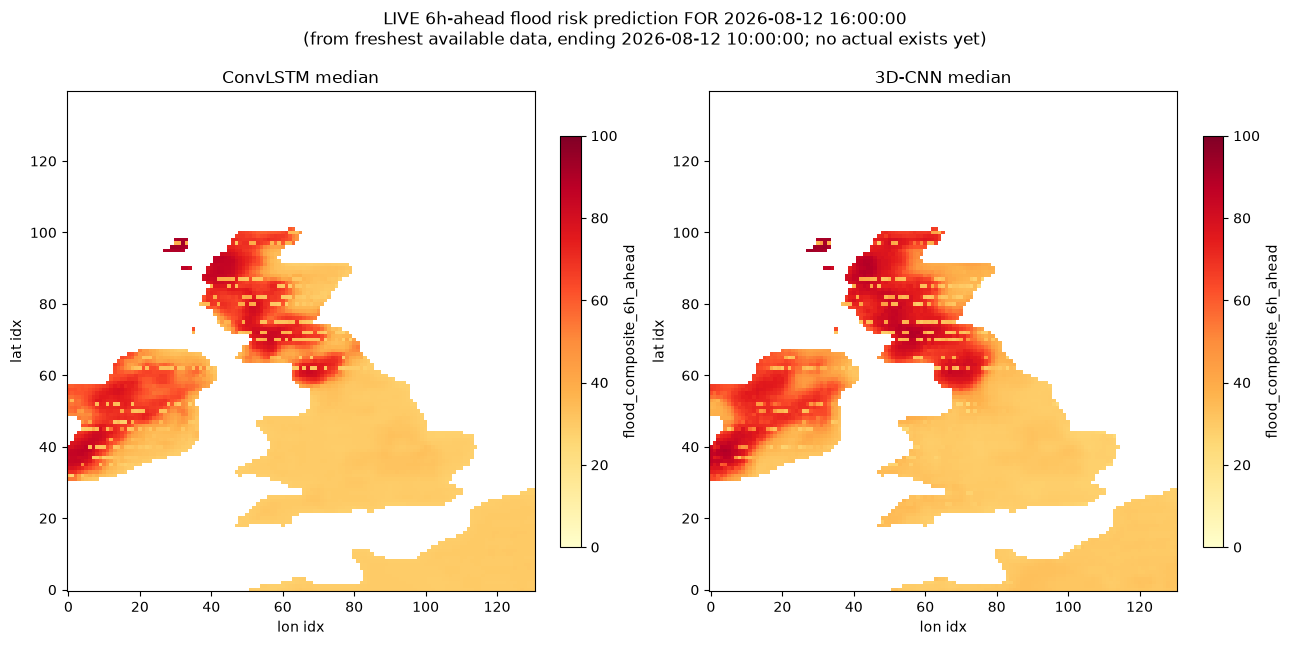


Peak-risk location (from valid model(s) only): lat=96, lon=32
  ConvLSTM: median=91.6  80% CI=[84.0, 99.2]  10-90% range=[79.2, 104.3]
  3D-CNN: median=94.1  80% CI=[85.8, 103.2]  10-90% range=[81.3, 109.5]

Saved: W:\Dissertation\Volumes\Seagate_2TB\model_logs\live_nowcast_map.png

Prediction is FOR: 2026-08-12 16:00:00


In [6]:
# EXAMPLE — run a live nowcast using the freshest data actually available
# ============================================================================
import subprocess
import sys

packages = [
    "xarray",
    "netcdf4",
    "scipy",
    "cfgrib",
    "eccodes",
    "h5netcdf",
]

for package in packages:
    try:
        __import__(package.replace("-", "_"))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed")

print("\n✓ All packages ready — restart kernel then re-run the nowcast cell")

result = run_live_nowcast()
print(f"\nPrediction is FOR: {result['predict_for']}")


In [7]:
# LIVE 6-HOUR ROLLING FORECAST ANIMATION (PYSTEPS-STYLE)
# ============================================================================
# pysteps itself couldn't be installed (Cython extensions need Microsoft
# Visual C++ Build Tools, unavailable here, and no prebuilt wheel exists
# for this Python/OS combo) — this replicates its default "STEPS"
# precipitation colourscale exactly (16 colours, same order, from
# pysteps/visualization/precipfields.py) without the dependency, remapped
# from precipitation's 0.08-160 mm/h onto flood_composite's 0-100 scale.
#
# FRAMING — read before interpreting the animation: the trained models
# only predict a single fixed +6h horizon; there is no native "t+1h, t+2h,
# ..., t+6h" trajectory from one forward pass. So "hour 0 to hour 6" here
# means: roll the REFERENCE time forward across 7 consecutive hours, and
# show EACH reference hour's own genuine +6h-ahead forecast —
#   frame 0 = forecast issued 6h ago, predicting right now
#   frame 6 = forecast issued now, predicting 6h from now (the headline
#             prediction from the cell above)
# Every frame is a real, independent model output on real fetched data —
# nothing is interpolated or fabricated between frames.
# ============================================================================
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from scipy.ndimage import gaussian_filter


def smooth_for_display(grid, sigma=0.8):
    """Cosmetic-only spatial smoothing applied at RENDER time — does not
    touch the underlying prediction data (frames[] keeps the real,
    unsmoothed values; only what gets drawn to the GIF is smoothed).
    Confirmed via diagnostics that isolated single-cell dips are genuine
    signal (both ConvLSTM and 3D-CNN — independently trained, no shared
    weights — agree on the exact same cells), not a data gap or model
    artifact; the discrete 16-level colour scale just renders moderate
    dips as a jarring jump. NaN-aware (mask-weighted) so land-cell values
    blend only with other land cells, never with the ocean/NaN region.
    The land/sea SHAPE itself is forced back to the original mask
    afterwards — smoothing must soften interior colour, never expand the
    visible coastline into the sea."""
    valid = np.isfinite(grid)
    filled = np.where(valid, grid, 0.0)
    num = gaussian_filter(filled, sigma=sigma)
    den = gaussian_filter(valid.astype(np.float64), sigma=sigma)
    smoothed = np.divide(num, den, out=np.zeros_like(num), where=den > 1e-6)
    return np.where(valid, smoothed, np.nan)

PYSTEPS_COLORS = [
    "#9C7E94", "#640064", "#AF00AF", "#DC00DC", "#3232C8", "#0064FF",
    "#009696", "#00C832", "#64FF00", "#96FF00", "#C8FF00", "#FFFF00",
    "#FFC800", "#FFA000", "#FF7D00", "#E11900",
]
PYSTEPS_LEVELS = np.linspace(0, 100, len(PYSTEPS_COLORS) + 1)
pysteps_cmap = mcolors.ListedColormap(PYSTEPS_COLORS, name="pysteps_flood")
pysteps_cmap.set_over("darkred")
pysteps_cmap.set_under("white")
pysteps_norm = mcolors.BoundaryNorm(PYSTEPS_LEVELS, pysteps_cmap.N)


def fetch_rolling_window(n_frames=7):
    """Fetch enough ERA5/IMERG history to build n_frames rolling forecasts,
    each needing its own SEQ_LEN-hour lookback (so total = SEQ_LEN +
    n_frames - 1 hours)."""
    total_hours = SEQ_LEN + (n_frames - 1)
    latest = find_latest_era5_hour()
    print(f"Fetching {total_hours}h of history (latest available: {latest})...")
    era5_by_name, _ = fetch_era5_window(latest, n_hours=total_hours)
    imerg_arr = fetch_imerg_window(latest, n_hours=total_hours)
    window = assemble_live_window(era5_by_name, imerg_arr)
    bad_rows, good_rows = detect_bad_rows(window)
    window_debanded = window.copy()
    for h in range(window.shape[0]):
        for ch in IMERG_CHANNELS:
            window_debanded[h, ch] = deband_rows_2d(window[h, ch], bad_rows, good_rows)
    # bad_rows/good_rows also returned so each frame's OUTPUT prediction grid
    # can be de-banded too (see build_rolling_animation) — de-banding only
    # the input still leaves those rows visually flat/stale across frames,
    # since the model reads smoothed-but-static input there each hour.
    return window_debanded, latest, bad_rows, good_rows


def full_domain_predict_from_window(model, full_window, mean, std, batch_size=64):
    """Same as full_domain_predict, but takes an already-sliced SEQ_LEN window
    directly rather than slicing out of the full test archive."""
    grid = np.full((N_LAT, N_LON), np.nan, dtype=np.float32)
    Xs = (full_window - mean) / std
    Xs_pad = np.pad(Xs, ((0, 0), (0, 0), (HALF, HALF), (HALF, HALF)), mode="reflect")
    with torch.no_grad():
        for i in range(0, len(all_land_cells), batch_size):
            batch_centres = all_land_cells[i:i+batch_size]
            xb = np.stack([Xs_pad[:, :, lat_c:lat_c+PATCH_SIZE, lon_c:lon_c+PATCH_SIZE]
                            for lat_c, lon_c in batch_centres])
            xb = torch.from_numpy(xb).float().to(device)
            pred = model(xb, sort_quantiles=True)
            med = pred[:, MED_IDX, HALF, HALF].cpu().numpy()
            for (lat_c, lon_c), val in zip(batch_centres, med):
                grid[lat_c, lon_c] = val
    return grid


def build_rolling_animation(window_debanded, latest_era5, bad_rows, good_rows,
                             model_name="ConvLSTM", n_frames=7, save_prefix="live_rolling"):
    model, mean, std = (convlstm, cl_mean, cl_std) if model_name == "ConvLSTM" else (cnn3d, c3_mean, c3_std)

    frames, frame_times = [], []
    VALID_RANGE = (-10, 150)
    for i in range(n_frames):
        seq_slice = window_debanded[i:i + SEQ_LEN]
        ref_time = latest_era5 - pd.Timedelta(hours=(n_frames - 1 - i))
        predict_time = ref_time + pd.Timedelta(hours=6)
        grid = full_domain_predict_from_window(model, seq_slice, mean, std)
        # De-band the OUTPUT prediction grid too, same rows as the input —
        # without this, cells in the known artifact latitude bands show a
        # flat/stale colour every frame instead of a real, moving forecast.
        grid = deband_rows_2d(grid, bad_rows, good_rows)
        finite = grid[np.isfinite(grid)]
        ok = not (finite.size and (finite.min() < VALID_RANGE[0] or finite.max() > VALID_RANGE[1]))
        status = "" if ok else " [INVALID]"
        print(f"  Frame {i}: reference {ref_time} -> predicting {predict_time}{status}")
        frames.append(grid)
        frame_times.append((predict_time, ok))

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(np.ma.masked_invalid(smooth_for_display(frames[0])), cmap=pysteps_cmap,
                    norm=pysteps_norm, origin="lower")
    cbar = plt.colorbar(im, ax=ax, ticks=PYSTEPS_LEVELS[::2], fraction=0.046, extend="max")
    cbar.set_label("flood_composite_6h_ahead")
    ax.set_xlabel("lon idx"); ax.set_ylabel("lat idx")
    t0, ok0 = frame_times[0]
    title = ax.set_title(f"{model_name} — forecast FOR {t0}  (h+0)" + ("" if ok0 else "  [INVALID]"))

    def update(i):
        im.set_data(np.ma.masked_invalid(smooth_for_display(frames[i])))
        t, ok = frame_times[i]
        title.set_text(f"{model_name} — forecast FOR {t}  (h+{i})" + ("" if ok else "  [INVALID]"))
        return im, title

    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=800, blit=False)
    gif_path = os.path.join(SEAGATE, "model_logs", f"{save_prefix}_{model_name.lower()}.gif")
    ani.save(gif_path, writer="pillow", fps=1.25)
    plt.close(fig)
    print(f"Saved animation ({n_frames} frames): {gif_path}")
    return frames, frame_times, gif_path


N_FRAMES = 7
print(f"\n{'='*70}\nFetching shared {SEQ_LEN + N_FRAMES - 1}h window for both models' animations\n{'='*70}")
_window_debanded, _latest_era5, _bad_rows, _good_rows = fetch_rolling_window(N_FRAMES)

print(f"\n{'='*70}\nBuilding rolling 0-6h forecast animation (ConvLSTM)\n{'='*70}")
frames_cl, times_cl, gif_cl = build_rolling_animation(
    _window_debanded, _latest_era5, _bad_rows, _good_rows, "ConvLSTM", n_frames=N_FRAMES)

if result.get("model_valid", {}).get("3D-CNN", True):
    print(f"\n{'='*70}\nBuilding rolling 0-6h forecast animation (3D-CNN)\n{'='*70}")
    frames_c3, times_c3, gif_c3 = build_rolling_animation(
        _window_debanded, _latest_era5, _bad_rows, _good_rows, "3D-CNN", n_frames=N_FRAMES)
else:
    print("\nSkipping 3D-CNN animation — flagged invalid for the current live query "
          "(see the safeguard in the cell above).")



Fetching shared 18h window for both models' animations


C:\Users\zd827032\AppData\Local\Temp\ipykernel_16184\3955655357.py:70: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  now = pd.Timestamp.utcnow().tz_localize(None)


Fetching 18h of history (latest available: 2026-08-12 10:00:00)...


Reusing cached W:\Dissertation\Volumes\Seagate_2TB\live_data\era5_live_2026081117_2026081210.nc


Upsampling ERA5 onto the exact 140x131 training grid (linear interp)...
ERA5 window shapes: {'u10': (18, 140, 131), 'v10': (18, 140, 131), 'd2m': (18, 140, 131), 't2m': (18, 140, 131), 'msl': (18, 140, 131), 'sst': (18, 140, 131), 'swvl1': (18, 140, 131), 'z': (18, 140, 131), 'cape': (18, 140, 131), 'tcwv': (18, 140, 131), 'lsm': (18, 140, 131), 'blh': (18, 140, 131), 'cp': (18, 140, 131)}


...

  Frame 3: reference 2026-08-12 07:00:00 -> predicting 2026-08-12 13:00:00


  Frame 4: reference 2026-08-12 08:00:00 -> predicting 2026-08-12 14:00:00


  Frame 5: reference 2026-08-12 09:00:00 -> predicting 2026-08-12 15:00:00


  Frame 6: reference 2026-08-12 10:00:00 -> predicting 2026-08-12 16:00:00


Saved animation (7 frames): W:\Dissertation\Volumes\Seagate_2TB\model_logs\live_rolling_3d-cnn.gif
